In [1]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

# ===== Config (as per your plan) =====
DROP_AA_COLUMNS = True            # Step 4 (optional but recommended)
DROP_GT_80_MISSING = True         # Step 5 (optional)
MISSINGNESS_THRESHOLD = 0.80

CORR_THRESHOLD = 0.95             # Step 8
RANDOM_SEED = 42


In [4]:

df = pd.read_csv("merged_clinvar_dbnsfp.csv")
print("Shape:", df.shape)
df.head()


Shape: (8508, 44)


,CHR,POS,REF,ALT,AAREF_x,AAALT_x,CLNSIG_x,AAREF_y,AAALT_y,CLNSIG_y,...,VARITY_ER,VARITY_R,VEST4,GMVP,1000GP3_AF,ESP6500_AA_AF,ESP6500_EA_AF,EXAC_AF,GNOMAD_EXOMES_AF,GNOMAD_GENOMES_AF
0,1,935779,G,A,G,S,0,G,S,0,...,0.080192,0.039468,0.185,0.039282,0.000399,0.000000,0.000814,0.002100,0.001400,0.002173
1,1,1336473,G,C,P,R,0,P,R,0,...,0.052677,0.024231,0.027,0.130734,0.008387,0.001768,0.009715,0.012810,0.015928,0.012737
2,1,1341803,C,T,A,T,0,A,T,0,...,0.033907,0.019594,0.027,0.294422,0.065695,0.205398,0.001051,0.017430,0.006409,0.062192
3,1,1520272,G,T,A,S,0,A,S,0,...,0.111080,0.115860,0.561,0.687842,0.000000,0.000000,0.000000,0.002167,0.002119,0.002282
4,1,1527718,A,G,N,S,1,N,S,1,...,0.258572,0.316597,0.827,0.871635,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
df.describe()

,POS,CLNSIG_x,CLNSIG_y,CADD,CLINPRED,DANN,DEOGEN2,EIGEN,FATHMM,FATHMM-MKL,...,VARITY_ER,VARITY_R,VEST4,GMVP,1000GP3_AF,ESP6500_AA_AF,ESP6500_EA_AF,EXAC_AF,GNOMAD_EXOMES_AF,GNOMAD_GENOMES_AF
count,8.508000e+03,8508.000000,8508.000000,8508.000000,5728.000000,8503.000000,4400.000000,7940.000000,5060.000000,8503.000000,...,4373.000000,4373.000000,8139.000000,5259.000000,8508.000000,8508.000000,8508.000000,8508.000000,8508.000000,8508.000000
mean,7.533960e+07,0.574871,0.574871,5.020653,0.408201,0.923275,0.374223,0.214599,-1.075364,0.717195,...,0.359222,0.384815,0.574949,0.539009,0.034933,0.033584,0.032244,0.034309,0.033821,0.034502
std,5.647365e+07,0.494392,0.494392,3.228533,0.442953,0.177929,0.352137,0.794942,2.984929,0.350797,...,0.339655,0.366915,0.352157,0.331194,0.140559,0.140435,0.137540,0.139856,0.140198,0.139703
min,8.990100e+04,0.000000,0.000000,-5.078367,0.000010,0.037441,0.000030,-3.218723,-12.400000,0.000040,...,0.013524,0.006909,0.004000,0.000108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.314397e+07,0.000000,0.000000,2.671692,0.019217,0.968558,0.059555,-0.278622,-3.290000,0.480410,...,0.066481,0.059635,0.204000,0.234556,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.775526e+07,1.000000,1.000000,4.774010,0.117007,0.994886,0.225733,0.478298,-0.910000,0.914880,...,0.190889,0.196171,0.702000,0.506796,0.000000,0.000000,0.000000,0.000008,0.000006,0.000007
75%,1.085970e+08,1.000000,1.000000,7.890118,0.989769,0.997777,0.732674,0.842796,1.192500,0.976655,...,0.705439,0.803268,0.909000,0.890824,0.000200,0.000000,0.000000,0.000248,0.000139,0.000206
max,2.474361e+08,1.000000,1.000000,17.485012,0.999979,0.999628,0.998353,1.311047,6.910000,0.999750,...,0.994348,0.998243,1.000000,0.999983,1.000000,0.999773,1.000000,1.000000,0.999999,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8508 entries, 0 to 8507
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CHR                8508 non-null   object 
 1   POS                8508 non-null   int64  
 2   REF                8508 non-null   object 
 3   ALT                8508 non-null   object 
 4   AAREF_x            8508 non-null   object 
 5   AAALT_x            8508 non-null   object 
 6   CLNSIG_x           8508 non-null   int64  
 7   AAREF_y            8508 non-null   object 
 8   AAALT_y            8508 non-null   object 
 9   CLNSIG_y           8508 non-null   int64  
 10  CADD               8508 non-null   float64
 11  CLINPRED           5728 non-null   float64
 12  DANN               8503 non-null   float64
 13  DEOGEN2            4400 non-null   float64
 14  EIGEN              7940 non-null   float64
 15  FATHMM             5060 non-null   float64
 16  FATHMM-MKL         8503 

In [7]:
df.isnull().sum()

CHR                     0
POS                     0
REF                     0
ALT                     0
AAREF_x                 0
AAALT_x                 0
CLNSIG_x                0
AAREF_y                 0
AAALT_y                 0
CLNSIG_y                0
CADD                    0
CLINPRED             2780
DANN                    5
DEOGEN2              4108
EIGEN                 568
FATHMM               3448
FATHMM-MKL              5
FATHMM-XF             639
GENOCANYON              5
LIST-S2              4070
M-CAP                4321
MVP                  4204
METALR               2961
METARNN              2945
METASVM              2961
MUTPRED              5953
MUTATIONASSESSOR     4103
PROVEAN              3499
POLYPHEN2_HDIV       3851
POLYPHEN2_HVAR       3851
PRIMATEAI            3046
REVEL                3489
SIFT                 3531
SIFT4G               3380
VARITY_ER            4135
VARITY_R             4135
VEST4                 369
GMVP                 3249
1000GP3_AF  

In [8]:
df = df.rename(columns={"CLNSIG_x": "CLNSIG"})
if "CLNSIG_y" in df.columns:
    df = df.drop(columns=["CLNSIG_y"])

print("Label counts:\n", df["CLNSIG"].value_counts())
print("Shape:", df.shape)


Label counts:
 CLNSIG
1    4891
0    3617
Name: count, dtype: int64
Shape: (8508, 43)


In [9]:
id_cols = ["CHR", "POS", "REF", "ALT"]
df = df.drop(columns=[c for c in id_cols if c in df.columns])

print("Dropped:", id_cols)
print("Shape:", df.shape)


Dropped: ['CHR', 'POS', 'REF', 'ALT']
Shape: (8508, 39)


In [10]:
aa_cols = ["AAREF_x", "AAALT_x", "AAREF_y", "AAALT_y"]
df = df.drop(columns=[c for c in aa_cols if c in df.columns])

print("Dropped AA columns:", aa_cols)
print("Shape:", df.shape)


Dropped AA columns: ['AAREF_x', 'AAALT_x', 'AAREF_y', 'AAALT_y']
Shape: (8508, 35)


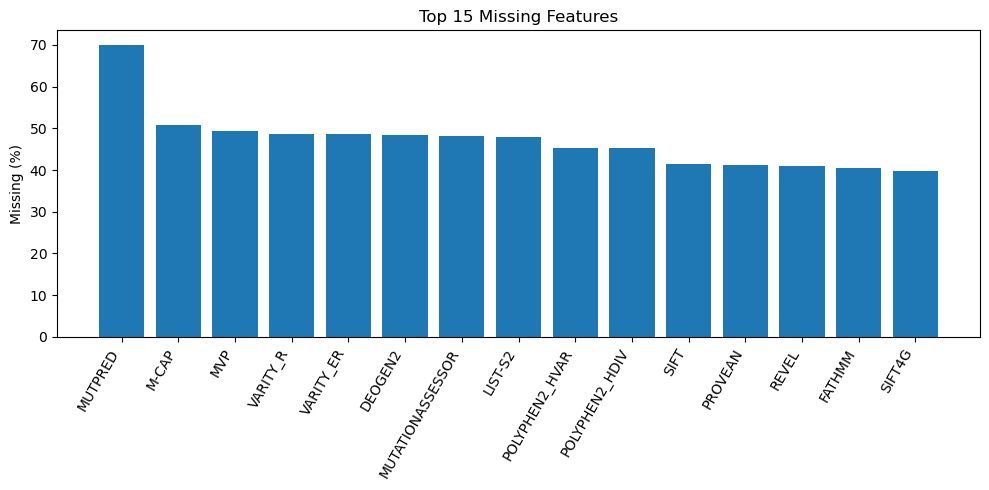

Dropped >80% missing: []
Shape: (8508, 35)


In [11]:
missing_frac = df.isna().mean().sort_values(ascending=False)
missing_report = pd.DataFrame({
    "feature": missing_frac.index,
    "missing_fraction": missing_frac.values,
    "missing_percent": (missing_frac.values*100).round(2)
})

# save report
missing_report.to_csv("metadata_missingness_report.csv", index=False)

# plot top-15 missing features
import matplotlib.pyplot as plt
top15 = missing_report.head(15)

plt.figure(figsize=(10,5))
plt.bar(top15["feature"], top15["missing_percent"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Missing (%)")
plt.title("Top 15 Missing Features")
plt.tight_layout()
plt.savefig("missingness_top15.png", dpi=300)
plt.show()

# optional: drop >80% missing columns (not label)
TH = 0.80
high_missing_cols = missing_frac[missing_frac > TH].index.tolist()
high_missing_cols = [c for c in high_missing_cols if c != "CLNSIG"]

df = df.drop(columns=high_missing_cols)

print("Dropped >80% missing:", high_missing_cols)
print("Shape:", df.shape)


In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# ensure label is kept
if "CLNSIG" not in numeric_cols:
    numeric_cols = ["CLNSIG"] + numeric_cols

df_num = df[numeric_cols].copy()

print("Numeric columns kept:", len(df_num.columns))
print("Shape:", df_num.shape)


Numeric columns kept: 35
Shape: (8508, 35)


In [13]:
from sklearn.impute import SimpleImputer

X = df_num.drop(columns=["CLNSIG"])
y = df_num["CLNSIG"].astype(int)

imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Any missing after imputation?", X_imp.isna().any().any())
print("X shape:", X_imp.shape)


Any missing after imputation? False
X shape: (8508, 34)


In [16]:
# Correlation matrix (absolute values help inspection)
corr_matrix = X_imp.corr()

print("Correlation matrix shape:", corr_matrix.shape)
corr_matrix.head()


Correlation matrix shape: (34, 34)


,CADD,CLINPRED,DANN,DEOGEN2,EIGEN,FATHMM,FATHMM-MKL,FATHMM-XF,GENOCANYON,LIST-S2,...,VARITY_ER,VARITY_R,VEST4,GMVP,1000GP3_AF,ESP6500_AA_AF,ESP6500_EA_AF,EXAC_AF,GNOMAD_EXOMES_AF,GNOMAD_GENOMES_AF
CADD,1.000000,0.101451,0.540779,0.102327,0.781493,-0.201968,0.581166,0.079236,0.135325,0.459740,...,0.092254,0.088921,0.679656,0.304604,-0.302139,-0.293552,-0.281050,-0.295736,-0.289263,-0.298460
CLINPRED,0.101451,1.000000,0.285843,0.696371,0.423543,-0.549578,0.418234,0.665764,0.194855,0.411823,...,0.710910,0.721362,0.521902,0.742109,-0.193979,-0.186923,-0.182832,-0.191394,-0.188146,-0.192705
DANN,0.540779,0.285843,1.000000,0.267777,0.657755,-0.269479,0.572579,0.328755,0.164537,0.568677,...,0.269257,0.272467,0.513501,0.415674,-0.430284,-0.434884,-0.398361,-0.420013,-0.408135,-0.425825
DEOGEN2,0.102327,0.696371,0.267777,1.000000,0.389362,-0.560315,0.372074,0.579486,0.161244,0.385172,...,0.832632,0.839053,0.450789,0.679148,-0.193723,-0.187526,-0.183050,-0.190878,-0.186840,-0.190841
EIGEN,0.781493,0.423543,0.657755,0.389362,1.000000,-0.375510,0.787081,0.461694,0.257895,0.625129,...,0.408689,0.405450,0.740445,0.568177,-0.386837,-0.375484,-0.355402,-0.375822,-0.367309,-0.380180


In [18]:
CORR_TH = 0.95

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > CORR_TH:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature_1", "Feature_2", "Correlation"]
).sort_values(by="Correlation", ascending=False)

print("Highly correlated feature pairs (>|0.95|):")
high_corr_df


Highly correlated feature pairs (>|0.95|):


,Feature_1,Feature_2,Correlation
9,GNOMAD_GENOMES_AF,EXAC_AF,0.989114
10,GNOMAD_GENOMES_AF,GNOMAD_EXOMES_AF,0.989082
6,GNOMAD_EXOMES_AF,EXAC_AF,0.989009
2,EXAC_AF,1000GP3_AF,0.983755
1,VARITY_R,VARITY_ER,0.981917
7,GNOMAD_GENOMES_AF,1000GP3_AF,0.981373
0,METASVM,METALR,0.976582
4,GNOMAD_EXOMES_AF,1000GP3_AF,0.967653
3,EXAC_AF,ESP6500_EA_AF,0.966471
5,GNOMAD_EXOMES_AF,ESP6500_EA_AF,0.963697


Features involved in high correlation: ['VARITY_R', 'METALR', 'ESP6500_EA_AF', 'GNOMAD_GENOMES_AF', 'METASVM', 'VARITY_ER', 'EXAC_AF', '1000GP3_AF', 'GNOMAD_EXOMES_AF']


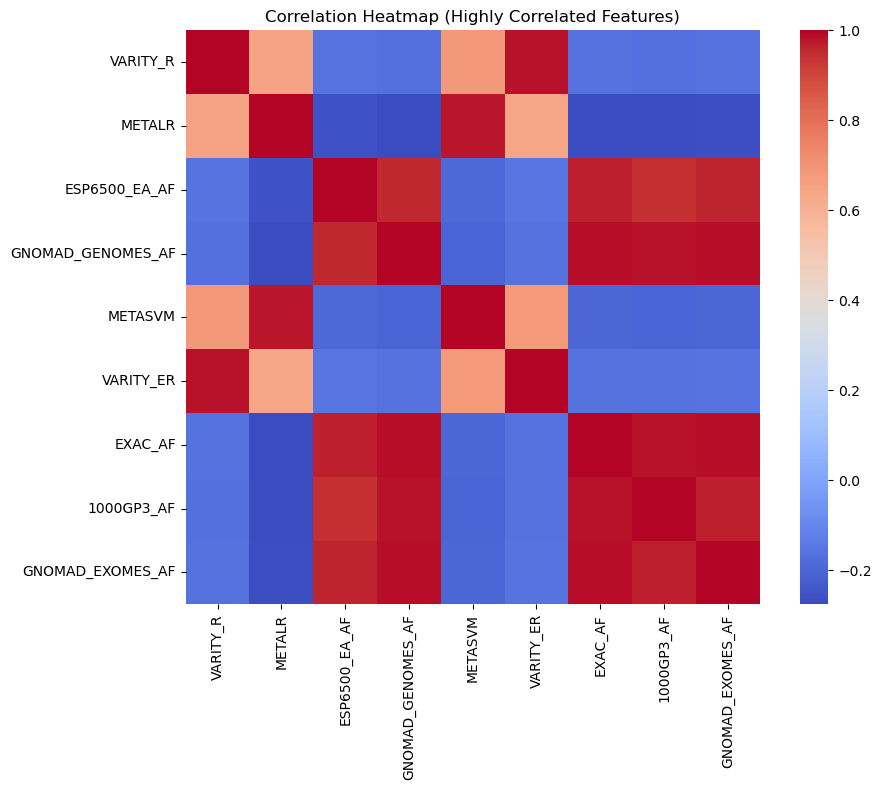

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique features involved in high correlation
corr_features = list(set(high_corr_df["Feature_1"]).union(
    set(high_corr_df["Feature_2"])
))

print("Features involved in high correlation:", corr_features)

if len(corr_features) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix.loc[corr_features, corr_features],
        cmap="coolwarm",
        annot=False,
        square=True
    )
    plt.title("Correlation Heatmap (Highly Correlated Features)")
    plt.tight_layout()
    plt.savefig("correlation_heatmap_high_corr.png", dpi=300)
    plt.show()
else:
    print("No feature pairs above correlation threshold.")


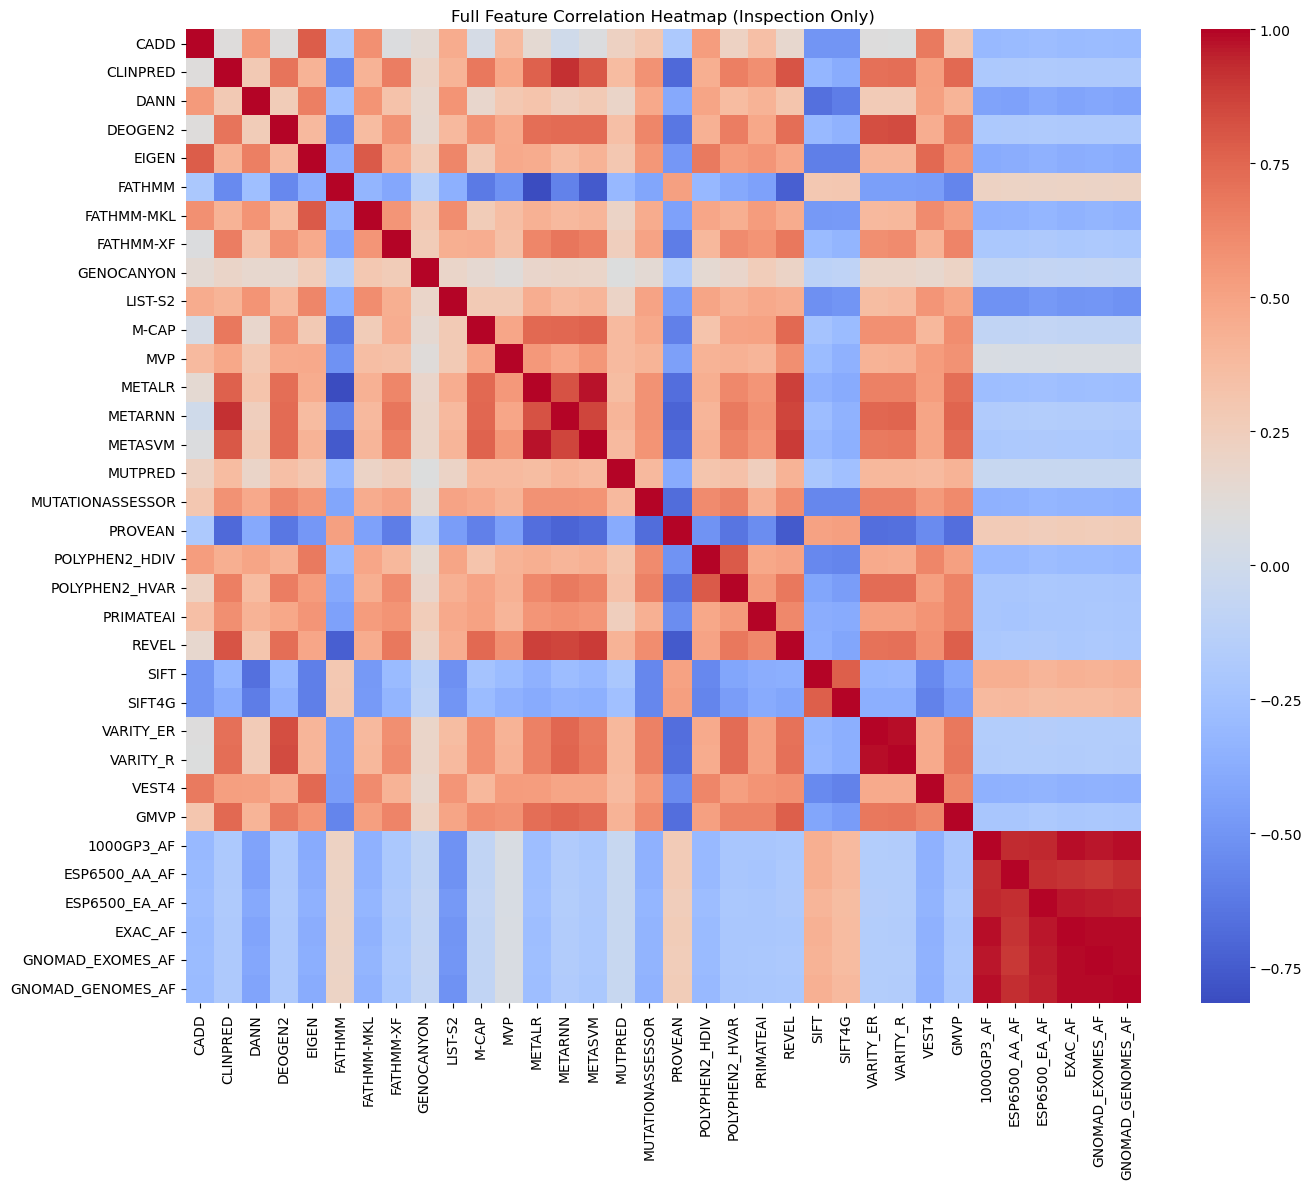

In [20]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", cbar=True)
plt.title("Full Feature Correlation Heatmap (Inspection Only)")
plt.tight_layout()
plt.show()


In [21]:
CORR_TH = 0.95

corr = X_imp.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

pairs = []
for col in upper.columns:
    high = upper.index[upper[col] > CORR_TH].tolist()
    for row in high:
        pairs.append((row, col, upper.loc[row, col]))

high_corr_df = pd.DataFrame(pairs, columns=["Feature_1", "Feature_2", "AbsCorr"])\
                 .sort_values("AbsCorr", ascending=False)

print("Highly correlated pairs (|corr| > 0.95):", len(high_corr_df))
high_corr_df.head(20)


Highly correlated pairs (|corr| > 0.95): 11


,Feature_1,Feature_2,AbsCorr
9,EXAC_AF,GNOMAD_GENOMES_AF,0.989114
10,GNOMAD_EXOMES_AF,GNOMAD_GENOMES_AF,0.989082
6,EXAC_AF,GNOMAD_EXOMES_AF,0.989009
2,1000GP3_AF,EXAC_AF,0.983755
1,VARITY_ER,VARITY_R,0.981917
7,1000GP3_AF,GNOMAD_GENOMES_AF,0.981373
0,METALR,METASVM,0.976582
4,1000GP3_AF,GNOMAD_EXOMES_AF,0.967653
3,ESP6500_EA_AF,EXAC_AF,0.966471
5,ESP6500_EA_AF,GNOMAD_EXOMES_AF,0.963697


In [22]:
# Missingness fraction from the ORIGINAL numeric DF before imputation
# df_num exists in your notebook earlier
missingness_frac = df_num.drop(columns=["CLNSIG"]).isna().mean()

missingness_df = pd.DataFrame({
    "feature": missingness_frac.index,
    "missing_fraction": missingness_frac.values
}).set_index("feature")

missingness_df.head()


,missing_fraction
feature,
CADD,0.000000
CLINPRED,0.326751
DANN,0.000588
DEOGEN2,0.482840
EIGEN,0.066761


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_base = X_imp.copy()
y_base = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=RANDOM_SEED, stratify=y_base
)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

rf_imp = pd.Series(rf.feature_importances_, index=X_base.columns).sort_values(ascending=False)
rf_imp.head(10)


EXAC_AF              0.159815
GNOMAD_EXOMES_AF     0.127887
GNOMAD_GENOMES_AF    0.123399
CLINPRED             0.100040
CADD                 0.079513
METARNN              0.073707
METASVM              0.045225
GMVP                 0.044502
VEST4                0.034293
METALR               0.027852
dtype: float64

In [24]:
drops = set()

for f1, f2, c in high_corr_df.itertuples(index=False):
    if f1 in drops or f2 in drops:
        continue

    m1 = missingness_df.loc[f1, "missing_fraction"] if f1 in missingness_df.index else 0.0
    m2 = missingness_df.loc[f2, "missing_fraction"] if f2 in missingness_df.index else 0.0

    if m1 > m2:
        drops.add(f1)
    elif m2 > m1:
        drops.add(f2)
    else:
        # tie -> keep higher RF importance
        i1 = rf_imp.get(f1, 0.0)
        i2 = rf_imp.get(f2, 0.0)
        if i1 >= i2:
            drops.add(f2)
        else:
            drops.add(f1)

drops = sorted(list(drops))
print("Final decided drops:", len(drops))
drops[:30]


Final decided drops: 6


['1000GP3_AF',
 'ESP6500_EA_AF',
 'GNOMAD_EXOMES_AF',
 'GNOMAD_GENOMES_AF',
 'METALR',
 'VARITY_ER']

In [25]:
pd.DataFrame({"dropped_feature": drops}).to_csv("metadata_corr_pruning_drops.csv", index=False)


In [26]:
X_pruned = X_imp.drop(columns=drops)
print("Before pruning:", X_imp.shape)
print("After pruning :", X_pruned.shape)


Before pruning: (8508, 34)
After pruning : (8508, 28)


In [30]:
X_pruned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8508 entries, 0 to 8507
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CADD              8508 non-null   float64
 1   CLINPRED          8508 non-null   float64
 2   DANN              8508 non-null   float64
 3   DEOGEN2           8508 non-null   float64
 4   EIGEN             8508 non-null   float64
 5   FATHMM            8508 non-null   float64
 6   FATHMM-MKL        8508 non-null   float64
 7   FATHMM-XF         8508 non-null   float64
 8   GENOCANYON        8508 non-null   float64
 9   LIST-S2           8508 non-null   float64
 10  M-CAP             8508 non-null   float64
 11  MVP               8508 non-null   float64
 12  METARNN           8508 non-null   float64
 13  METASVM           8508 non-null   float64
 14  MUTPRED           8508 non-null   float64
 15  MUTATIONASSESSOR  8508 non-null   float64
 16  PROVEAN           8508 non-null   float64


In [32]:
# Combine features and label
final_df = pd.concat([X_pruned, y.reset_index(drop=True)], axis=1)

print("Final cleaned dataset shape:", final_df.shape)
final_df.head()


Final cleaned dataset shape: (8508, 29)


,CADD,CLINPRED,DANN,DEOGEN2,EIGEN,FATHMM,FATHMM-MKL,FATHMM-XF,GENOCANYON,LIST-S2,...,PRIMATEAI,REVEL,SIFT,SIFT4G,VARITY_R,VEST4,GMVP,ESP6500_AA_AF,EXAC_AF,CLNSIG
0,1.567354,0.014292,0.936413,0.000149,-1.031323,-0.91,0.06333,0.097977,0.878646,0.771423,...,0.324202,0.255,1.000,1.000,0.039468,0.185,0.039282,0.000000,0.002100,0
1,0.489450,0.006406,0.640866,0.316573,-1.130670,3.58,0.03455,0.096930,0.044466,0.742826,...,0.571282,0.048,0.399,0.503,0.024231,0.027,0.130734,0.001768,0.012810,0
2,0.194078,0.003687,0.497617,0.255858,-1.336275,3.53,0.63256,0.089446,0.145888,0.630737,...,0.418382,0.035,0.636,0.428,0.019594,0.027,0.294422,0.205398,0.017430,0
3,2.800539,0.033521,0.796507,0.008686,0.032262,1.42,0.98794,0.838092,0.999602,0.763224,...,0.610907,0.292,0.618,0.786,0.115860,0.561,0.687842,0.000000,0.002167,0
4,3.921156,0.996360,0.998581,0.702464,0.737925,-1.81,0.95587,0.889191,0.999924,0.974503,...,0.554751,0.893,0.004,0.006,0.316597,0.827,0.871635,0.000000,0.000000,1


In [34]:
final_df.to_csv(
    "cleaned_numeric_clinvar_dbnsfp_final.csv",
    index=False
)

print(" Saved: cleaned_numeric_clinvar_dbnsfp_final.csv")


 Saved: cleaned_numeric_clinvar_dbnsfp_final.csv


In [35]:
X_pruned.to_csv(
    "X_clinvar_cleaned_28features.csv",
    index=False
)

y.to_csv(
    "y_clinvar_labels.csv",
    index=False
)

print("✅ Saved X and y separately")


✅ Saved X and y separately


In [36]:
pd.DataFrame(
    {"feature_name": X_pruned.columns}
).to_csv(
    "metadata_final_28_features.csv",
    index=False
)

print("✅ Saved feature list: metadata_final_28_features.csv")


✅ Saved feature list: metadata_final_28_features.csv


In [37]:
final_df.info()
print("Total missing values:", final_df.isna().sum().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8508 entries, 0 to 8507
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CADD              8508 non-null   float64
 1   CLINPRED          8508 non-null   float64
 2   DANN              8508 non-null   float64
 3   DEOGEN2           8508 non-null   float64
 4   EIGEN             8508 non-null   float64
 5   FATHMM            8508 non-null   float64
 6   FATHMM-MKL        8508 non-null   float64
 7   FATHMM-XF         8508 non-null   float64
 8   GENOCANYON        8508 non-null   float64
 9   LIST-S2           8508 non-null   float64
 10  M-CAP             8508 non-null   float64
 11  MVP               8508 non-null   float64
 12  METARNN           8508 non-null   float64
 13  METASVM           8508 non-null   float64
 14  MUTPRED           8508 non-null   float64
 15  MUTATIONASSESSOR  8508 non-null   float64
 16  PROVEAN           8508 non-null   float64
